<a href="https://colab.research.google.com/github/Dinesh-Rodriguez/Menstrual-abnormality-detection-using-cycle-pattern/blob/main/yuga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random


random.seed(42)
np.random.seed(42)

num_users = 50
cycles_per_user = 125

flow_options = ['light', 'medium', 'heavy']
mood_options = ['stable', 'anxious', 'irritable']
pain_scores = [0, 1, 2, 3]
data = []

for user_id in range(1, num_users+1):
    cycle_start = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 30))
    for cycle_num in range(cycles_per_user):

        if random.random() < 0.15:
            cycle_length = np.random.randint(21, 50)
            irregular_flag = 1
        else:
            cycle_length = np.random.randint(25, 36)
            irregular_flag = 0

        period_length = np.random.randint(3, 8)
        pain_score = random.choice(pain_scores)
        flow = random.choice(flow_options)
        mood = random.choice(mood_options)
        pcos_risk = 1 if irregular_flag and random.random() < 0.3 else 0
        thyroid_risk = 1 if irregular_flag and random.random() < 0.2 else 0

        data.append({
            'user_id': user_id,
            'cycle_start_date': cycle_start.strftime('%Y-%m-%d'),
            'cycle_length_days': cycle_length,
            'period_length_days': period_length,
            'pain_score': pain_score,
            'flow_intensity': flow,
            'mood': mood,
            'irregular_flag': irregular_flag,
            'pcos_risk': pcos_risk,
            'thyroid_risk': thyroid_risk
        })

        cycle_start += timedelta(days=cycle_length)

df_time_series = pd.DataFrame(data)
df_time_series.to_csv("menstrual_cycle_time_series_synthetic.csv", index=False)
print("Synthetic dataset saved as menstrual_cycle_time_series_synthetic.csv")


Synthetic dataset saved as menstrual_cycle_time_series_synthetic.csv


In [2]:
pip install pandas numpy matplotlib seaborn statsmodels tensorflow scikit-learn


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

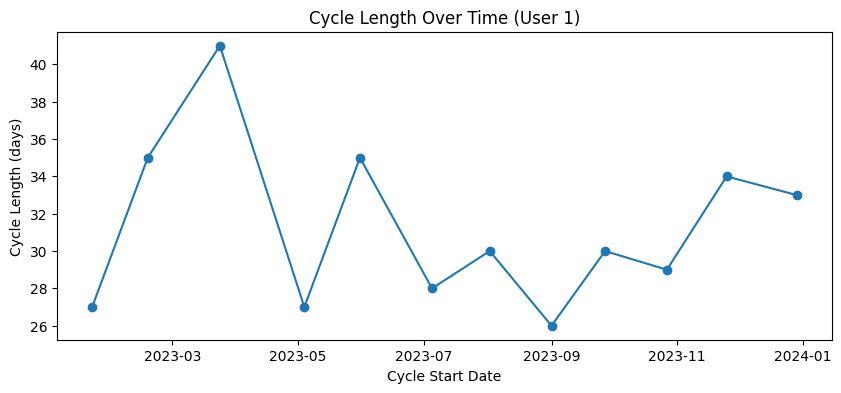

In [10]:
# 1. Load your synthetic dataset CSV
df = pd.read_csv('menstrual_cycle_time_series_synthetic.csv', parse_dates=['cycle_start_date'])

# Sort by user and date
df = df.sort_values(['user_id', 'cycle_start_date'])

# 2. Data preprocessing

# Encode categorical columns
le_flow = LabelEncoder()
df['flow_encoded'] = le_flow.fit_transform(df['flow_intensity'])

le_mood = LabelEncoder()
df['mood_encoded'] = le_mood.fit_transform(df['mood'])

# 3. EDA: Plot cycle length for a single user
user_example = df[df['user_id'] == 1]
plt.figure(figsize=(10,4))
plt.plot(user_example['cycle_start_date'], user_example['cycle_length_days'], marker='o')
plt.title('Cycle Length Over Time (User 1)')
plt.xlabel('Cycle Start Date')
plt.ylabel('Cycle Length (days)')
plt.show()

In [11]:
def create_lag_features(df, lag=3):
    X, y = [], []
    for user in df['user_id'].unique():
        user_data = df[df['user_id'] == user]
        user_data = user_data.reset_index(drop=True)
        for i in range(len(user_data) - lag):
            features = []
            for j in range(lag):
                features.extend([
                    user_data.loc[i+j, 'cycle_length_days'],
                    user_data.loc[i+j, 'period_length_days'],
                    user_data.loc[i+j, 'pain_score'],
                    user_data.loc[i+j, 'flow_encoded'],
                    user_data.loc[i+j, 'mood_encoded']
                ])
            X.append(features)
            y.append(user_data.loc[i+lag, 'irregular_flag'])
    return np.array(X), np.array(y)

X, y = create_lag_features(df)

In [12]:



# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape for LSTM [samples, timesteps, features_per_timestep]
timesteps = 3
features_per_timestep = 5
X_train = X_train.reshape((-1, timesteps, features_per_timestep))
X_test = X_test.reshape((-1, timesteps, features_per_timestep))

# 5. Build LSTM Model for irregularity classification
model = Sequential([
    LSTM(64, input_shape=(timesteps, features_per_timestep)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping callback
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[es])

# 6. Evaluate model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

# 7. ARIMA Example for user 1 - Predict next cycle length
user1 = df[df['user_id'] == 1].set_index('cycle_start_date')
cycle_lengths = user1['cycle_length_days']

model_arima = ARIMA(cycle_lengths, order=(1,0,0))  # simple AR(1)
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

forecast = model_arima_fit.forecast(steps=1)
print(f"Predicted next cycle length for user 1: {forecast.iloc[0]:.2f} days")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.6988 - loss: 0.6701 - val_accuracy: 0.9028 - val_loss: 0.6188
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8637 - loss: 0.5993 - val_accuracy: 0.9028 - val_loss: 0.5474
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8586 - loss: 0.5350 - val_accuracy: 0.9028 - val_loss: 0.4623
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8476 - loss: 0.4617 - val_accuracy: 0.9028 - val_loss: 0.3872
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8883 - loss: 0.3660 - val_accuracy: 0.9028 - val_loss: 0.3652
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8749 - loss: 0.3462 - val_accuracy: 0.9028 - val_loss: 0.3629
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8639 - loss: 0.3849 - val_accuracy: 0.9028 - val_loss: 0.3619
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8621 - loss: 0.3525 - val_accuracy: 0.9028 - va

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/statsmode

In [4]:
import pandas as pd

# Assuming df sorted by user_id and cycle_start_date
df['cycle_start_date'] = pd.to_datetime(df['cycle_start_date'])

# Rolling mean and std of cycle_length per user (window=3 cycles)
df['cycle_length_rolling_mean'] = df.groupby('user_id')['cycle_length_days'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['cycle_length_rolling_std'] = df.groupby('user_id')['cycle_length_days'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))

# Lag feature: difference between current and previous cycle length
df['cycle_length_diff'] = df.groupby('user_id')['cycle_length_days'].diff().fillna(0)

# Extract month and quarter as features
df['month'] = df['cycle_start_date'].dt.month
df['quarter'] = df['cycle_start_date'].dt.quarter


In [5]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, features_per_timestep)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
